<a href="https://colab.research.google.com/github/nacrocker/automated-segmentation/blob/max-tree-synthetic-signal-tests-in-colab/maxtree_tests_with_synthetic_data_and_noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
from scipy.signal import chirp

def blackman_vs_tau(tau):
    """Blackman window vs normalized time (0 <= tau <= 1)
       This gives numpy.blackman(M) == blackman_vs_tau(taus) for taus = (numpy.arange(1-M, M, 2)/(M-1)/2) + 0.5
    """
    return 0.42 + 0.5*np.cos(2*np.pi*(tau-0.5)) + 0.08* np.cos(4*np.pi*(tau-0.5)) #0 <= tau <= 1

def make_noise(mean, std, shape, noise_generator = np.random.normal):
    return noise_generator(mean, std, t.shape)

import typing
class Chirp(typing.NamedTuple):
    amp: float = 1.0
    envlf: typing.Callable[...,typing.Any] = blackman_vs_tau
    t0: float = 0.0  #seconds
    t1: float = 1.0  #seconds
    f0: float = 1000.0 #Hz
    f1: float  = 11000.0 #Hz
    phi: float = 0.0 #degrees
    method: str = 'quadratic'
    vertex_zero: bool = True

    def __call__(self,t):
        """make chirp, c(t):
           t:  array-like float
           for t such that self.t0 <= t <= self.t1:
               c(t) = amp*envlf((t-self.t0)/(self.t1-self.t0))*
               scipy.signal.chirp(t-self.t0, self.f0, self.t1-self.t0, self.f1, method=self.method, phi=self.phi, vertex_zero=self.vertex_zero)
               where envlf is a continuous function that defines values for 0<= t <= 1.
                   the default, blackman_vs_tau, is inspired by the blackmann window where, for 0 <= t <= 1:
                   blackman_vs_tau(t) = 0.42 + 0.5*cos(2*np.pi*(t-0.5)) + 0.08*cos(4*np.pi*(t-0.5))
              self.method defaults to quadratic and self.vertex_zero defaults to true.
           for t such that t <=self.t0 or self.t1 <= t: c(t) = 0
        """
        import numpy as np
        from scipy.signal import chirp
        t = np.asarray(t).flatten()
        nt = t.size
        sig=np.zeros((nt,),dtype=float)
        it0 = np.searchsorted(t,self.t0)
        it1 = np.searchsorted(t,self.t1,side='right')-1
        ntch=it1-it0+1
        if ntch > 0:
            envl=self.envlf((t[it0:it0+ntch]-self.t0)/(self.t1-self.t0))
            sig[it0:it0+ntch] = self.amp*envl*chirp(t[it0:it0+ntch]-self.t0, self.f0, self.t1-self.t0, self.f1, method=self.method, phi=self.phi, vertex_zero=self.vertex_zero)
        return sig

def add_funcsigs(sigfunclist,t):
    sig = 0.0
    for sgf in sigfunclist: sig+=sgf(t)
    return sig



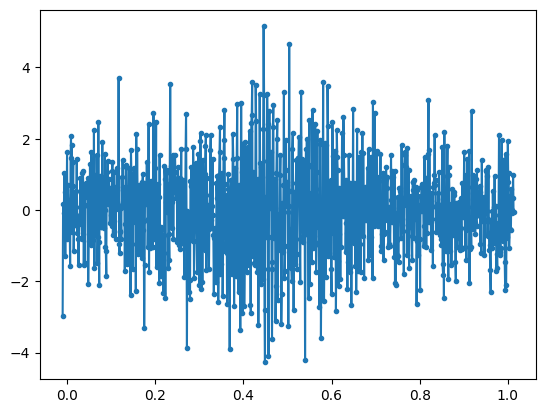

In [50]:
t=np.arange(0,1024/1000,0.001)-.01
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=int(np.ceil(np.sqrt(nt)))
noise_mean=0
noise_std=1.0

chirps=[]

t0=t[int(nt/16)]
t1=t[int(nt/16)+int(nt*3/4)-1]
chirps.append(Chirp(amp=2.0, t0=t0, t1=t1, f0=0.3*fN, f1=0.9*fN))

t0=t[int(nt/8)]
t1=t[int(nt/8)+int(nt*3/4)-1]
chirps.append(Chirp(amp=1.5, t0=t0, t1=t1, f0=0.15*fN, f1=0.7*fN))

sig0 = add_funcsigs(chirps,t)
noise = make_noise(noise_mean, noise_std, t.shape)
sig = sig0 + noise



import matplotlib.pyplot as plt
plt.figure()
plt.plot(t,sig,'.-')

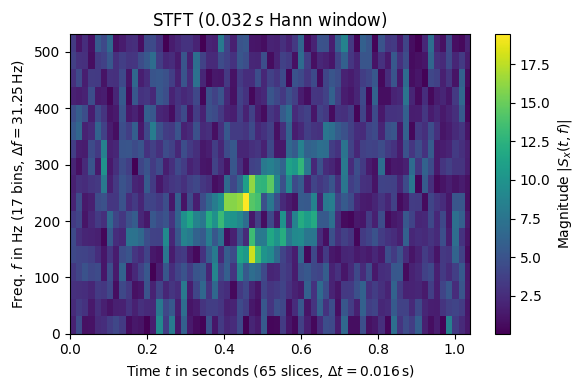

In [52]:
from scipy.signal import ShortTimeFFT
t0=t[0]
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=(int(np.ceil(np.sqrt(nt))) // 2) * 2
noverlap=int(nfft/2)

SFT = ShortTimeFFT.from_window(win_param='hann', fs=fs, nperseg=nfft,noverlap=noverlap)
sigstft = SFT.stft(sig)

N=nt
fig1, ax1 = plt.subplots(figsize=(6., 4.))  # enlarge plot a bit
t_lo, t_hi = SFT.extent(N)[:2]  # time range of plot
ax1.set_title(rf"STFT ({SFT.m_num*SFT.T:g}$\,s$ Hann window)")
ax1.set(xlabel=f"Time $t$ in seconds ({SFT.p_num(N)} slices, " +
               rf"$\Delta t = {SFT.delta_t:g}\,$s)",
        ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, " +
               rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
        xlim=(t_lo, t_hi))

im1 = ax1.imshow(np.abs(sigstft), origin='lower', aspect='auto',
                 extent=SFT.extent(N), cmap='viridis')
plotLeg=False
if (False):
    ##freq should be chirp frequencies vs t)
    ax1.plot(t, freq, 'r--', alpha=.5, label='$f_i(t)$')
    plotLeg=True

fig1.colorbar(im1, label="Magnitude $|S_x(t, f)|$")

if (False):
    # Shade areas where window slices stick out to the side:
    for t0_, t1_ in [(t_lo, SFT.lower_border_end[0] * SFT.T),
                    (SFT.upper_border_begin(N)[0] * SFT.T, t_hi)]:
        ax1.axvspan(t0_, t1_, color='w', linewidth=0, alpha=.2)
    for t_ in [0, N * SFT.T]:  # mark signal borders with vertical line:
        ax1.axvline(t_, color='y', linestyle='--', alpha=0.5)

if plotLeg: ax1.legend()
fig1.tight_layout()
plt.show()

In [46]:
foo=ShortTimeFFT (np.ones(32), 16, fs=1)
print(foo.lower_border_end,foo.m_num)

from scipy.signal import get_window
print(get_window('hann', 32)[0:1])

bar=ShortTimeFFT.from_window('hann', 1, 32, noverlap=16)
print(bar.lower_border_end,bar.m_num)

(16, 1) 32
[0.]
(17, 1) 32


[-5.00e-02  6.94e-18  5.00e-02  1.00e-01  1.50e-01  2.00e-01  2.50e-01  3.00e-01  3.50e-01  4.00e-01  4.50e-01
  5.00e-01  5.50e-01  6.00e-01  6.50e-01  7.00e-01  7.50e-01  8.00e-01  8.50e-01  9.00e-01  9.50e-01  1.00e+00
  1.05e+00  1.10e+00  1.15e+00]
[ 0.00e+00  2.23e-33 -7.44e-03 -3.82e-02 -6.06e-02  1.17e-01  6.84e-01  3.35e-01 -1.32e+00 -1.08e+00  1.03e+00
  8.13e-01 -7.76e-01 -3.22e-01  7.27e-01  3.72e-01 -2.63e-01 -2.22e-01  4.16e-03  3.82e-02  7.44e-03  0.00e+00
  0.00e+00  0.00e+00  0.00e+00]


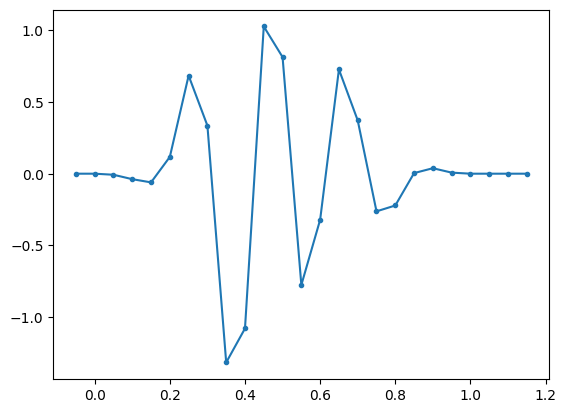

In [35]:
# @title
t=np.linspace(-.1,1.1,25)+.05
chrpd0 = Chirp(t0=0.0,t1=1.0,f0=3.0,f1=3.0,phi=90.0)
chrpd1 = Chirp(amp=2.0,t0=0.1,t1=0.9,f0=5.0,f1=3.0,phi=90.0)

chrpds = [chrpd0,chrpd1]
sig = add_funcsigs(chrpds,t)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(t,sig,'.-')

with np.printoptions(precision=2, linewidth=120):
    print(t)
    print(sig)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [ ]:
from skimage.morphology import max_tree


In [ ]:
import numpy as np
print(np.maximum([1,1],[2,0]))

[2 1]


In [1]:
import typing
class AddConst(typing.NamedTuple):
    const: float = 0.0
    def __call__(self,arg):
        return arg+self.const


add1 = AddConst(1.0)
print(add1(2.0))


3.0


[-5.00e-02  6.94e-18  5.00e-02  1.00e-01  1.50e-01  2.00e-01  2.50e-01  3.00e-01  3.50e-01  4.00e-01  4.50e-01
  5.00e-01  5.50e-01  6.00e-01  6.50e-01  7.00e-01  7.50e-01  8.00e-01  8.50e-01  9.00e-01  9.50e-01  1.00e+00
  1.05e+00  1.10e+00  1.15e+00]
[ 0.00e+00  2.23e-33 -7.44e-03 -3.82e-02 -3.13e-02  1.18e-01  3.40e-01  3.00e-01 -2.13e-01 -8.08e-01 -7.77e-01
  3.12e-15  7.77e-01  8.08e-01  2.13e-01 -3.00e-01 -3.40e-01 -1.18e-01  3.13e-02  3.82e-02  7.44e-03  0.00e+00
  0.00e+00  0.00e+00  0.00e+00]


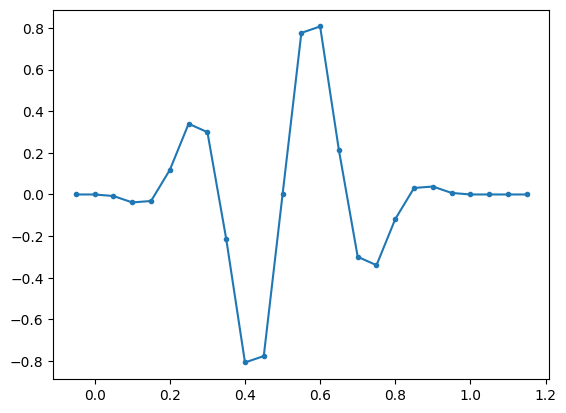

In [6]:
# @title
import numpy as np
from scipy.signal import chirp

def blackman_vs_tau(tau):
    """Blackman window vs normalized time (0 <= tau <= 1)
       This gives numpy.blackman(M) == blackman_vs_tau(taus) for taus = (numpy.arange(1-M, M, 2)/(M-1)/2) + 0.5
    """
    return 0.42 + 0.5*np.cos(2*np.pi*(tau-0.5)) + 0.08* np.cos(4*np.pi*(tau-0.5)) #0 <= tau <= 1

def mkchirpdesc(amp=1.0,f0=.25,f1=.75,t0=.1,t1=0.9,phi=0.0,vert0=True):
    return dict(amp=amp,f0=f0,f1=f1,t0=t0,t1=t1,phi=phi,vert0=vert0)

def make_sig(t, chirpdescs = None, phi=0):
    nt=len(t)
    sig=np.zeros((nt,),dtype=float)
    t=np.asarray(t)

    if chirpdescs is None:
        return sig

    for imd,chrp in enumerate(chirpdescs):
        amp,f0,f1,t0,t1,phi,vert0=(chrp[k] for k in ['amp','f0','f1','t0','t1','phi','vert0'])

        it0 = np.searchsorted(t,t0)
        it1 = np.searchsorted(t,t1,side='right')-1
        ntch=it1-it0+1
        if ntch > 0:
            envl=blackman_vs_tau((t[it0:it0+ntch]-t0)/(t1-t0))
            sig[it0:it0+ntch]+=amp*envl*chirp(t[it0:it0+ntch]-t0, f0, t1-t0, f1, method='quadratic', phi=phi, vertex_zero=vert0)
        return sig

import matplotlib.pyplot as plt
t=np.linspace(-.1,1.1,25)+.05
chrpd0 = mkchirpdesc(t0=0.0,t1=1.0,f0=3.0,f1=3.0,phi=90.0)
chrpds = [chrpd0]
sig = make_sig(t,chrpds)
plt.figure()
plt.plot(t,sig,'.-')
with np.printoptions(precision=2, linewidth=120):
    print(t)
    print(sig)